# Document layout: boxes, categories, reading order

dots.ocr returns a JSON array describing the page — one object per element with
its `bbox`, `category` and the text inside it.

Budget enough tokens: a dense page needs thousands, and a run that stops early
truncates the JSON mid-array. The parser below salvages every complete object
rather than discarding the page.

In [1]:
import json
import re

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

from mlx_vlm import apply_chat_template, generate, load

MODEL = "mlx-community/dots.ocr-4bit"
PAGE = "../images/paper.png"

LAYOUT_PROMPT = (
    "Please output the layout information from the PDF image, including each "
    "layout element's bbox, its category, and the corresponding text content "
    "within the bbox."
)

model, processor = load(MODEL)

In [2]:
prompt = apply_chat_template(processor, model.config, LAYOUT_PROMPT, num_images=1)
result = generate(
    model, processor, prompt, image=[PAGE], max_tokens=4096, temperature=0.0
)


def parse_layout(text):
    text = text.strip().removeprefix("```json").removeprefix("```").removesuffix("```")
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return [
            json.loads(m.group(0))
            for m in re.finditer(r"\{[^{}]*\}", text)
            if m.group(0).count('"bbox"')
        ]


elements = parse_layout(result.text)
print(f"{len(elements)} elements, {result.generation_tps:.1f} tok/s, {result.peak_memory:.2f} GB peak")
for element in elements[:8]:
    print(f"  {element['category']:<10} {element['bbox']}")

14 elements, 314.3 tok/s, 4.57 GB peak
  Title      [79, 114, 1066, 219]
  Text       [147, 331, 361, 361]
  Text       [502, 331, 701, 363]
  Text       [801, 331, 1049, 361]
  Text       [181, 363, 319, 389]
  Text       [464, 363, 741, 390]
  Text       [857, 363, 992, 389]
  Text       [94, 393, 404, 419]


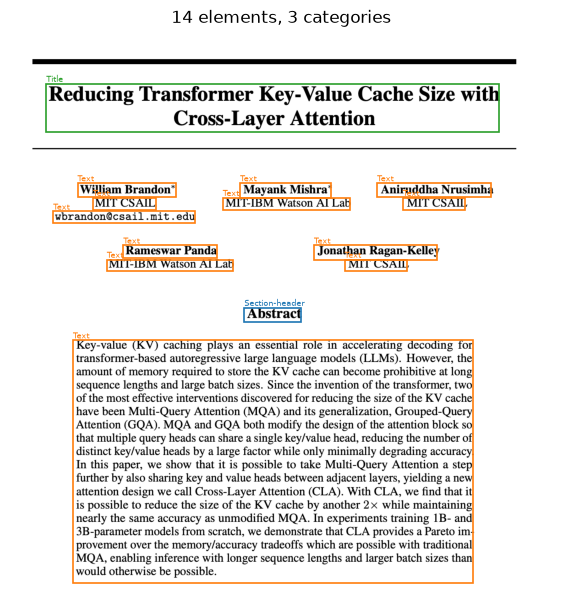

In [3]:
image = Image.open(PAGE)
categories = sorted({e["category"] for e in elements})
colours = dict(zip(categories, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(image)
for element in elements:
    x1, y1, x2, y2 = element["bbox"]
    colour = colours[element["category"]]
    ax.add_patch(
        patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=1.2, edgecolor=colour, facecolor="none"
        )
    )
    ax.text(x1, max(y1 - 4, 0), element["category"], color=colour, fontsize=6)
ax.axis("off")
ax.set_title(f"{len(elements)} elements, {len(categories)} categories")
plt.show()

## Reading order

The array comes back in reading order, so joining the `text` fields gives a
linear transcript — including across multi-column pages, where naive
top-to-bottom OCR scrambles.

In [4]:
print("\n\n".join(e["text"] for e in elements if e.get("text"))[:1200])

# Reducing Transformer Key-Value Cache Size with Cross-Layer Attention

**William Brandon***

**Mayank Mishra***

**Aniruddha Nrusingha**

MIT CSAIL

MIT-IBM Watson AI Lab

MIT CSAIL

wbrandon@csail.mit.edu

**Rameswar Panda**

**Jonathan Ragan-Kelley**

MIT-IBM Watson AI Lab

MIT CSAIL

## Abstract

Key-value (KV) caching plays an essential role in accelerating decoding for transformer-based autoregressive large language models (LLMs). However, the amount of memory required to store the KV cache can become prohibitive at long sequence lengths and large batch sizes. Since the invention of the transformer, two of the most effective interventions discovered for reducing the size of the KV cache have been Multi-Query Attention (MQA) and its generalization, Grouped-Query Attention (GQA). MQA and GQA both modify the design of the attention block so that multiple query heads can share a single key/value head, reducing the number of distinct key/value heads by a large factor while only minima

## Straight to Markdown

A plain instruction skips the JSON layer when all you want is the page as prose.

In [5]:
prompt = apply_chat_template(
    processor,
    model.config,
    "Convert this page to clean Markdown while preserving reading order.",
    num_images=1,
)
markdown = generate(
    model, processor, prompt, image=[PAGE], max_tokens=800, temperature=0.0
)
print(markdown.text.strip()[:1000])

# Reducing Transformer Key-Value Cache Size with Cross-Layer Attention

**William Brandon***  
MIT CSAIL  
wbrandon@csail.mit.edu

**Mayank Mishra***  
MIT-IBM Watson AI Lab

**Aniruddha Nrusingha**  
MIT CSAIL

**Rameswar Panda**  
MIT-IBM Watson AI Lab

**Jonathan Ragan-Kelley**  
MIT CSAIL

## Abstract

Key-value (KV) caching plays an essential role in accelerating decoding for transformer-based autoregressive large language models (LLMs). However, the amount of memory required to store the KV cache can become prohibitive at long sequence lengths and large batch sizes. Since the invention of the transformer, two of the most effective interventions discovered for reducing the size of the KV cache have been Multi-Query Attention (MQA) and its generalization, Grouped-Query Attention (GQA). MQA and GQA both modify the design of the attention block so that multiple query heads can share a single key/value head, reducing the number of distinct key/value heads by a large factor while only 